# 🏨 EDA — exploración de datos (final, sobre `src`)

> **Capa final del proyecto.** Este notebook pertenece a la capa **final**: usa el
> paquete `src/` (la *fuente única de verdad*). La exploración 'a mano', estilo
> `recursos/`, está en `notebooks/playground/`. Aquí mostramos el EDA que
> **justifica las decisiones del pipeline de producción**. Glosario:
> `../docs/glosario.md`.

### El problema
Predecir si una **reserva de hotel se cancelará** (`is_canceled = 1`) o no
(`is_canceled = 0`): clasificación **binaria**. Los datos: ~119 000 reservas de un
*City Hotel* y un *Resort Hotel* en Portugal (2015–2017). Cada fila es una reserva.

### Dos capas, una sola verdad
A diferencia del *playground* (independiente, con *plotly*), aquí **importamos el
contrato de `src/`**: las constantes (`config`) y el cargador (`load_raw_data`) son
**exactamente** los que usa el pipeline de producción. Así, lo que veamos aquí no
es una exploración paralela, sino la **justificación** de lo que el código hace. Para
el detalle visual usamos **matplotlib / seaborn** (no plotly).

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

# Contrato de produccion: misma fuente unica de verdad que la API y el pipeline.
from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_raw_data

## 1. Carga (datos crudos)

Cargamos el CSV con **el mismo cargador que usa producción** (`load_raw_data`).
No es una lectura ad hoc: interpreta los *tokens* de ausencia definidos en
`config.NA_TOKENS` igual que en el entrenamiento, de modo que lo que exploramos
coincide con lo que el modelo ve.

In [2]:
df = load_raw_data()
print('Dimensiones (filas, columnas):', df.shape)
df.head()

Dimensiones (filas, columnas): (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Para cada columna: tipo de dato, nº de valores distintos y nº de huecos (nulos).
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'n_nulos': df.isna().sum(),
})
resumen

,dtype,n_unicos,n_nulos
hotel,object,2,0
is_canceled,int64,2,0
lead_time,int64,479,0
arrival_date_year,int64,3,0
arrival_date_month,object,12,0
arrival_date_week_number,int64,53,0
arrival_date_day_of_month,int64,31,0
stays_in_weekend_nights,int64,17,0
stays_in_week_nights,int64,35,0
adults,int64,14,0


## 2. La variable objetivo: `config.TARGET_COLUMN`

La **variable objetivo** (*target*) es lo que queremos predecir. La tomamos del
contrato (`config.TARGET_COLUMN`), no de un literal escrito a mano. Miramos su
**balance de clases**: si una clase domina, hablamos de **desbalance**, y eso
condiciona cómo entrenamos y evaluamos.

Variable objetivo (config.TARGET_COLUMN): is_canceled

Conteo:
 is_canceled
0    75166
1    44224

Proporcion:
 is_canceled
0    0.63
1    0.37


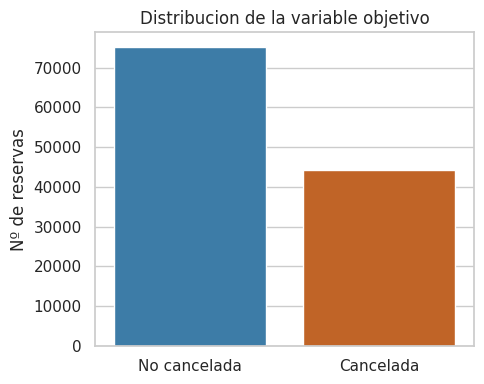

In [4]:
target = config.TARGET_COLUMN
print('Variable objetivo (config.TARGET_COLUMN):', target)

conteo = df[target].value_counts().sort_index()
prop = df[target].value_counts(normalize=True).sort_index()
print('\nConteo:\n', conteo.to_string())
print('\nProporcion:\n', prop.round(3).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=target, data=df, ax=ax, palette=['#2c7fb8', '#d95f0e'])
ax.set_xticklabels(config.CLASS_LABELS_SHORT)
ax.set_title('Distribucion de la variable objetivo')
ax.set_xlabel(''); ax.set_ylabel('Nº de reservas')
plt.tight_layout(); plt.show()

**Observación.** Alrededor del **37 % de las reservas se cancelan**: es un
**desbalance moderado**. Dos consecuencias de diseño que el `src` ya implementa:

- **Partición estratificada** (`data_loader.split_data`, con `stratify=y`): el ~37 %
  se mantiene en *train* y *test*.
- Métrica principal **ROC-AUC** (`config.PRIMARY_METRIC`), no la *accuracy*: con
  clases desbalanceadas, un modelo que dijera "nunca se cancela" ya acertaría el
  63 % sin aprender nada.

## 3. Valores ausentes (huecos en los datos)

Un **valor ausente** (*nulo*, *NaN*) es una celda vacía. Cuántos hay y dónde decide
si **rellenamos** (*imputamos*) o **descartamos** la columna.

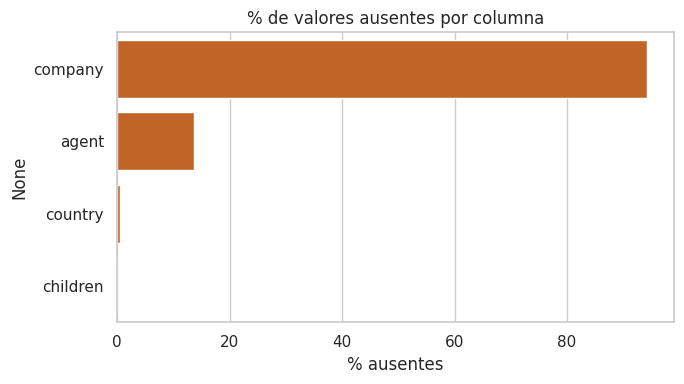

company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color='#d95f0e')
ax.set_title('% de valores ausentes por columna')
ax.set_xlabel('% ausentes'); plt.tight_layout(); plt.show()
missing.round(2)

**Decisiones (implementadas en `src`).**
- `company` está vacía en ~**94 %** de las filas → se **elimina**
  (`config.DROP_COLUMNS`): apenas aporta información.
- `agent` (~14 %) es un identificador de agencia: se trata como **categoría**
  (`config.CATEGORICAL_COLUMNS`) y los huecos se marcan como `"Unknown"`
  (`data_loader.normalize_categoricals`).
- `country` (~0.4 %) y `children` (residual) se **imputan** en el preprocesado.

## 4. Fuga de información (*data leakage*) — ¡muy importante!

La **fuga de información** (*data leakage*) es un error grave: el modelo usa, sin
querer, datos que **revelan la respuesta** o que **no existirían al predecir en
real**. Parecería buenísimo... pero haría trampa.

El `src` ya marca estas columnas en `config.LEAKAGE_COLUMNS` y las elimina siempre.
Comprobamos *por qué* con una **tabla cruzada** de `reservation_status` frente al
*target*:

In [6]:
print('Columnas marcadas como fuga (config.LEAKAGE_COLUMNS):', config.LEAKAGE_COLUMNS)
print('Lista completa de columnas que se eliminan (config.DROP_COLUMNS):', config.DROP_COLUMNS)

pd.crosstab(df['reservation_status'], df[config.TARGET_COLUMN])

Columnas marcadas como fuga (config.LEAKAGE_COLUMNS): ['reservation_status', 'reservation_status_date']
Lista completa de columnas que se eliminan (config.DROP_COLUMNS): ['company', 'reservation_status', 'reservation_status_date']


is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


**Confirmado.** `reservation_status = 'Canceled'` coincide **exactamente** con
`is_canceled = 1` (y `No-Show` también es cancelación). Esta columna *es* la
respuesta: si la dejásemos, el modelo acertaría ~100 % de forma **engañosa e
inútil**. Por eso figura en `config.LEAKAGE_COLUMNS` y `data_loader.clean_data` la
elimina siempre (junto con `reservation_status_date`).

## 5. ¿Por qué excluir `arrival_date_year`?

De las cuatro fechas de llegada, `month`, `week_number` y `day_of_month` aportan
**estacionalidad**, pero el **año** no aporta valor real. Por eso **no aparece** en
`config.NUMERIC_COLUMNS`. Aquí mostramos la evidencia que justifica esa decisión
registrada en el contrato:

In [7]:
print('arrival_date_year esta en NUMERIC_COLUMNS?',
      'arrival_date_year' in config.NUMERIC_COLUMNS)

# (1) tasa de cancelacion por año  y  (2) que meses cubre cada año.
meses = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']
tasa = df.groupby('arrival_date_year')[config.TARGET_COLUMN].agg(['size', 'mean']).round(4)
tasa.columns = ['n_reservas', 'tasa_cancelacion']
print('\nTasa de cancelacion por año:')
print(tasa.to_string())
print('\nMeses cubiertos por cada año:')
for anio, sub in df.groupby('arrival_date_year'):
    presentes = sorted(set(sub['arrival_date_month']), key=meses.index)
    print(f'  {anio}: {len(presentes):2d} meses -> {presentes}')

arrival_date_year esta en NUMERIC_COLUMNS? False

Tasa de cancelacion por año:
                   n_reservas  tasa_cancelacion
arrival_date_year                              
2015                    21996            0.3702
2016                    56707            0.3586
2017                    40687            0.3870

Meses cubiertos por cada año:
  2015:  6 meses -> ['July', 'August', 'September', 'October', 'November', 'December']
  2016: 12 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
  2017:  8 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']


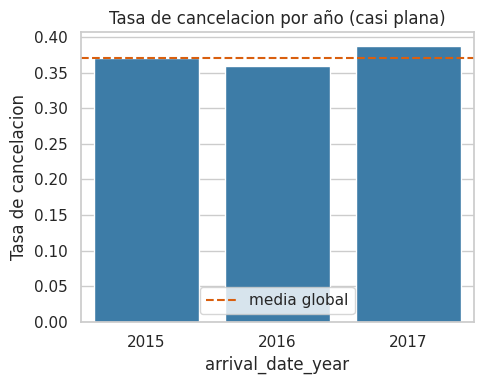

In [8]:
# La tasa de cancelacion por año es practicamente plana (~37 %).
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=tasa.index.astype(str), y=tasa['tasa_cancelacion'], ax=ax, color='#2c7fb8')
ax.axhline(df[config.TARGET_COLUMN].mean(), ls='--', color='#d95f0e',
           label='media global')
ax.set_title('Tasa de cancelacion por año (casi plana)')
ax.set_xlabel('arrival_date_year'); ax.set_ylabel('Tasa de cancelacion')
ax.legend(); plt.tight_layout(); plt.show()

**Decisión: excluir `arrival_date_year`** (no está en `config.NUMERIC_COLUMNS`).
Tres motivos:

1. **Apenas discrimina:** la tasa de cancelación es casi idéntica los tres años
   (≈ 37 %, 36 %, 39 %).
2. **No generaliza:** el modelo debe puntuar reservas *futuras*; un año no visto al
   entrenar (2018+) no tiene un valor interpretable.
3. **Va confundida con la estación:** **2015 solo cubre jul–dic y 2017 solo
   ene–ago** (años parciales). Esa señal estacional ya la recogen `month` y
   `week_number`, que **sí se repiten** cada año.

Por eso el contrato la deja fuera y el preprocesador nunca la usa como característica.

## 6. Variables numéricas y correlaciones

Las **numéricas** del pipeline son exactamente `config.NUMERIC_COLUMNS` (sin
`arrival_date_year`, como vimos). La **correlación** mide de −1 a +1 cómo se mueven
juntas dos variables; si dos están casi a +1/−1 aportan lo mismo y podríamos
descartar una. Pintamos el triángulo inferior para no repetir.

In [9]:
num = [c for c in config.NUMERIC_COLUMNS if c in df.columns]
print('Numericas del contrato (config.NUMERIC_COLUMNS):', len(num))
df[num].describe().T.round(2)

Numericas del contrato (config.NUMERIC_COLUMNS): 16


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0
is_repeated_guest,119390.0,0.03,0.18,0.00,0.00,0.00,0.0,1.0
previous_cancellations,119390.0,0.09,0.84,0.00,0.00,0.00,0.0,26.0


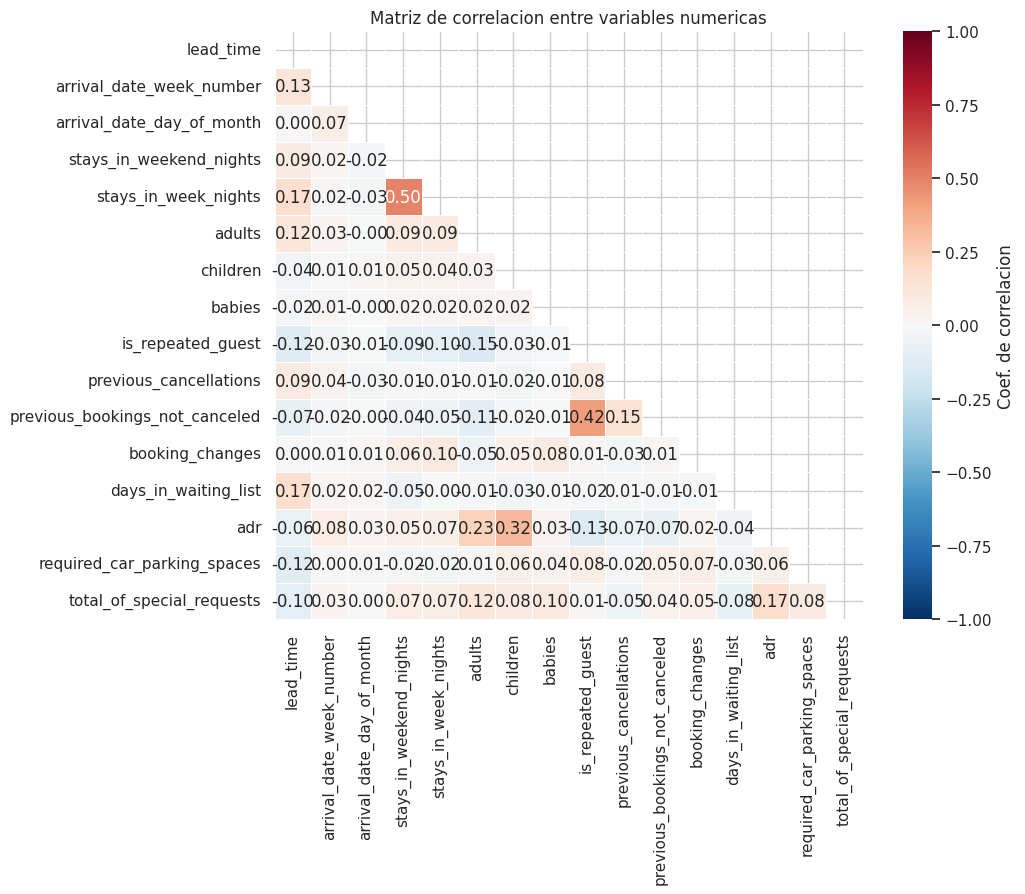

In [10]:
# Matriz de correlacion entre las numericas del contrato (triangulo inferior).
corr = df[num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'label': 'Coef. de correlacion'}, ax=ax)
ax.set_title('Matriz de correlacion entre variables numericas')
plt.tight_layout(); plt.show()

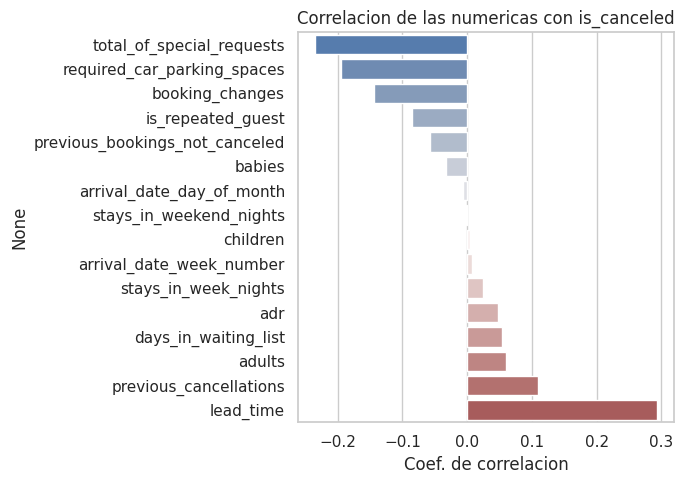

In [11]:
# Correlacion de cada numerica con el target: positiva = a mas valor, mas cancela.
corr_target = df[num + [config.TARGET_COLUMN]].corr()[config.TARGET_COLUMN]
corr_target = corr_target.drop(config.TARGET_COLUMN).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, ax=ax, palette='vlag')
ax.set_title('Correlacion de las numericas con ' + config.TARGET_COLUMN)
ax.set_xlabel('Coef. de correlacion'); plt.tight_layout(); plt.show()

**Lectura.** No hay parejas **fuertemente redundantes** (ningún |coef.| ≈ 0.9), así
que no eliminamos ninguna numérica por redundancia. Respecto al *target*,
`lead_time` correlaciona **positivamente** (reservar con mucha antelación → más
cancelaciones), mientras que `total_of_special_requests` y
`required_car_parking_spaces` lo hacen **al revés** (señales de cliente comprometido,
que cancela menos). Como las escalas son muy distintas (`lead_time` en cientos,
`adr` en decenas), el preprocesado las **estandariza**.

## 7. Variables categóricas y tasa de cancelación

Las **categóricas** son etiquetas de texto; las del pipeline son
`config.CATEGORICAL_COLUMNS`. Para unas pocas calculamos su **tasa de cancelación**
(proporción de reservas que se cancelan en cada categoría), que indica su poder
predictivo.

Categoricas del contrato (config.CATEGORICAL_COLUMNS): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'agent']


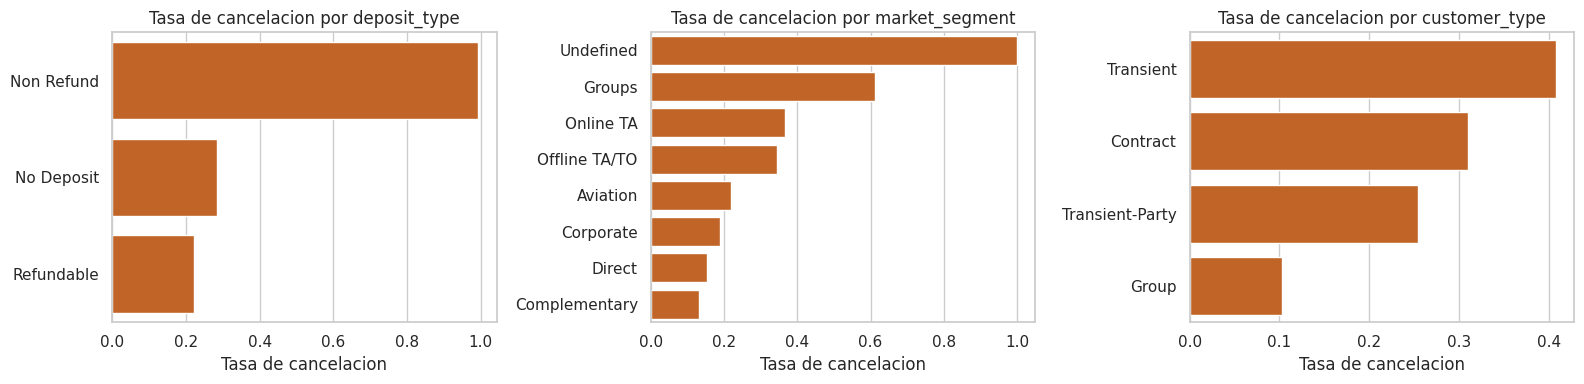

In [12]:
print('Categoricas del contrato (config.CATEGORICAL_COLUMNS):', config.CATEGORICAL_COLUMNS)

def tasa_cancelacion(col, ax):
    tasa = df.groupby(col)[config.TARGET_COLUMN].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color='#d95f0e')
    ax.set_title(f'Tasa de cancelacion por {col}')
    ax.set_xlabel('Tasa de cancelacion'); ax.set_ylabel('')

cols = ['deposit_type', 'market_segment', 'customer_type']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for col, ax in zip(cols, axes.ravel()):
    tasa_cancelacion(col, ax)
plt.tight_layout(); plt.show()

**Hallazgos clave.**
- `deposit_type = 'Non Refund'` (depósito no reembolsable) tiene una tasa de
  cancelación **altísima** (≈ **99 %**): es la categórica más predictiva. No es
  *leakage* (se conoce al reservar), sino que **identifica un perfil concreto** de
  reservas (grupos/agencias portuguesas, mucha antelación) que casi siempre se
  anulan — correlación, no causalidad.
- Los segmentos `Groups` y `Offline TA/TO` cancelan más que `Direct`/`Corporate`.
- El cliente `Transient` (suelto) cancela más que `Contract`/`Group`.

Las categóricas de **alta cardinalidad** (`country`, `agent`) se gestionan con
*one-hot* limitado a `config.MAX_OHE_CATEGORIES` categorías (las raras se agrupan).

## 8. Conclusiones → decisiones del pipeline (`src`)

Cada hallazgo del EDA está **ya implementado** en el código de producción. Esa es la
razón de ser de este notebook de capa final: documentar el *porqué* de cada decisión.

- **Clases desbalanceadas (~37 %)** → partición **estratificada**
  (`data_loader.split_data`, `stratify=y`) y métrica principal **ROC-AUC**
  (`config.PRIMARY_METRIC`).
- **`reservation_status*` filtran la respuesta** → eliminadas siempre
  (`config.LEAKAGE_COLUMNS` → `config.DROP_COLUMNS`, en `data_loader.clean_data`).
- **`company` ~94 % vacía** → eliminada (`config.DROP_COLUMNS`).
- **`arrival_date_year` no generaliza** (años parciales, confundida con la estación)
  → **excluida** de las características (no está en `config.NUMERIC_COLUMNS`).
- **`agent` es un ID con huecos** → categoría con huecos → `"Unknown"`
  (`data_loader.normalize_categoricals`).
- **Huecos en `country`, `children`** → imputados en el preprocesado.
- **Escalas muy dispares** → estandarización (`StandardScaler`).
- **Categóricas de alta cardinalidad** (`country`, `agent`) → *one-hot* limitado a
  `config.MAX_OHE_CATEGORIES`.
- **Reservas con 0 huéspedes** → eliminadas (`data_loader.clean_data`).

Cada modelo se estudia en su notebook (`02`–`06`) y todos se comparan en
`07_comparativa_modelos.ipynb`. El ganador es **XGBoost** (ROC-AUC ≈ 0.9614).